## Preprocessing Overview

The goal of this notebook is to get the clean Airbnb demand dataset ready for modeling.

Most of the major cleaning already happened in the data wrangling and EDA notebooks. At this point, I am checking the target, selecting features, reviewing amenity columns, and preparing the dataset for train-test splitting.

The target is `reviews_per_month`, which I'm using in place of booking data to determine demand. Since missing or zero review activity does not give a clear demand signal, those listings were removed before this notebook.

### Steps Completed

- Loaded the clean demand dataset from the EDA notebook.
- Checked that `reviews_per_month` has no missing or zero values.
- Used `np.log1p()` on `reviews_per_month` to reduce skew.
- Selected baseline features, including property size, location, host signals, booking settings, and review score.
- Reviewed amenity columns and kept amenities that appeared often enough to be useful.
- Used one-hot encoded room type columns created during data wrangling.
- Used binary amenity columns created during data wrangling.
- Scaled numeric features for models like Ridge and Lasso.
- Split the data into training and testing sets so model performance can be checked on unseen data.

## Imports 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Clean Data

In [2]:
df = pd.read_csv('../data/processed/airbnb_eda_clean.csv')

## Inspect Dataset

In [3]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_wifi,amenity_workspace,city,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,1,0,Asheville,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,Asheville,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,1,0,Asheville,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,Asheville,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,Asheville,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153594 entries, 0 to 153593
Data columns (total 82 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             153594 non-null  int64  
 1   host_id                        153594 non-null  int64  
 2   room_type_hotel_room           153594 non-null  int64  
 3   room_type_private_room         153594 non-null  int64  
 4   room_type_shared_room          153594 non-null  int64  
 5   accommodates                   153594 non-null  int64  
 6   bedrooms                       153594 non-null  float64
 7   beds                           153594 non-null  float64
 8   bathrooms                      153594 non-null  float64
 9   host_is_superhost              153594 non-null  float64
 10  host_response_time_ord         153594 non-null  float64
 11  price                          153594 non-null  float64
 12  latitude                       153594 non

In [5]:
df.shape

(153594, 82)

In [6]:
# checking that the demand target is clean before preprocessing
print('Missing reviews_per_month:', df['reviews_per_month'].isna().sum())
print('Zero reviews_per_month:', (df['reviews_per_month'] == 0).sum())
print('Minimum reviews_per_month:', df['reviews_per_month'].min())
print('Maximum reviews_per_month:', df['reviews_per_month'].max())

Missing reviews_per_month: 0
Zero reviews_per_month: 0
Minimum reviews_per_month: 0.01
Maximum reviews_per_month: 101.42


## Define Target

The target is `reviews_per_month`, which I am using as a proxy for Airbnb demand.

This notebook uses the clean demand dataset, so listings with missing or zero reviews per month have already been removed. I am using `np.log1p()` because the target is still right-skewed.

In [7]:
# using log-transformed reviews per month as the demand target
y = np.log1p(df['reviews_per_month'])

In [8]:
y.describe()

count    153594.000000
mean          0.777696
std           0.565417
min           0.009950
25%           0.270027
50%           0.693147
75%           1.205971
max           4.629082
Name: reviews_per_month, dtype: float64

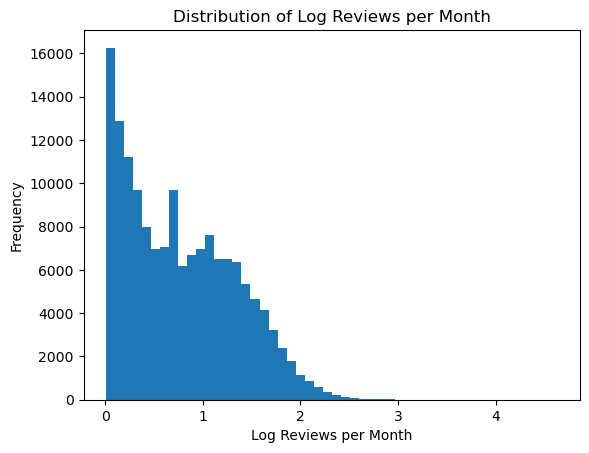

In [9]:
plt.hist(y, bins=50)
plt.title('Distribution of Log Reviews per Month')
plt.xlabel('Log Reviews per Month')
plt.ylabel('Frequency')
plt.show()

# checking the target distribution before modeling
# clearly skewed - could run another model on active listings with reviews > 0, but will leave as is for now. 

## Feature Selection 

In [10]:
# selecting core listing features for the baseline model
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'review_scores_rating']

X = df[features]

In [11]:
X.describe()

,accommodates,bedrooms,beds,bathrooms,latitude,longitude,host_is_superhost,instant_bookable,review_scores_rating
count,153594.00000,153594.000000,153594.000000,153594.000000,153594.000000,153594.000000,153594.000000,153594.000000,153594.000000
mean,4.35907,1.671387,2.390998,1.501045,32.921445,-104.585691,0.406487,0.338522,4.723268
std,2.85863,1.179674,1.763551,0.807564,6.806523,27.500779,0.491179,0.473209,0.542027
min,0.00000,0.000000,1.000000,0.000000,18.920250,-159.714620,0.000000,0.000000,0.000000
25%,2.00000,1.000000,1.000000,1.000000,29.932440,-118.343930,0.000000,0.000000,4.670000
50%,4.00000,1.000000,2.000000,1.000000,34.063235,-97.723294,0.000000,0.000000,4.870000
75%,6.00000,2.000000,3.000000,2.000000,39.762950,-80.147552,1.000000,1.000000,5.000000
max,16.00000,12.000000,14.000000,8.000000,45.729839,-71.073130,1.000000,1.000000,5.000000


In [12]:
df_sd = df[df['city'] == 'San Diego']
df_sd.describe()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_view_water,amenity_washer,amenity_wifi,amenity_workspace,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Amenity Exploration

In [13]:
# Identify amenity columns
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

len(amenity_cols)

56

In [14]:
# Check most common amenities
amenity_frequency = df[amenity_cols].mean().sort_values(ascending=False)

amenity_frequency.head(20)

amenity_wifi                     0.986282
amenity_smoke_alarm              0.944178
amenity_kitchen                  0.910752
amenity_essentials               0.910667
amenity_air_conditioning         0.902516
amenity_tv                       0.900465
amenity_cooking_basics           0.826354
amenity_hangers                  0.826198
amenity_refrigerator             0.822623
amenity_hair_dryer               0.815982
amenity_parking_free             0.794959
amenity_hot_water                0.792791
amenity_iron                     0.786671
amenity_toiletries               0.782309
amenity_heating                  0.772309
amenity_coffee_maker             0.763506
amenity_carbon_monoxide_alarm    0.747054
amenity_microwave                0.733661
amenity_washer                   0.719436
amenity_bed_linens               0.697456
dtype: float64

In [15]:
# Keep amenities between 5% and 95% frequency
selected_amenities = amenity_frequency[
    (amenity_frequency > 0.05) & (amenity_frequency < 0.95)
].index.tolist()

len(selected_amenities)

49

In [16]:
df.groupby('amenity_smoke_alarm')['reviews_per_month'].mean()

amenity_smoke_alarm
0    0.993954
1    1.625506
Name: reviews_per_month, dtype: float64

In [17]:
rare_amenities = amenity_frequency[(amenity_frequency < 0.05)].index.tolist()

rare_amenities

['amenity_view_other',
 'amenity_view_water',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

### Amenity Analysis

I looked at amenity frequency to decide which amenity columns were useful enough to keep. I removed rare amenities that show up in less than 5% of listings because they may be too sparse to model well.

I considered removing basic amenities like smoke alarms or hot water, but I kept common features for now because they may still signal listing quality, completeness, or host effort.

This section is mostly exploratory. Later, I am more interested in grouping amenities into broader product themes, such as family-friendly, work-friendly, leisure, premium, or longer-stay features.

<b> Tiers</b>: I'm considering implementing tiered amenities (along with grouping beds/baths/pricing) to see if listings can be grouped a certain way and if they drive price differently - this way we can evaluate different listing types (basic listings versus luxury listings), then within those groups see how images affect bookings.

1. Baseline: expected essentials (wifi, kitchen, linens)
2. Comfort / Functional: longer-stay or practical (washer, parking, workspace)
3. Premium / Leisure: differentiators (pool, hot tub, beach access)
4. Niche / Experiential: rare, location-specific (ski access, EV charger)

### Train-Test Split

The dataset was split into training and testing sets (80/20 split) to evaluate model performance on unseen data and prevent overfitting.

In [18]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
# Add selected amenities to feature set
features_with_amenities = features + selected_amenities
X2 = df[features_with_amenities]

### Scaling

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

amenities_scaled = scaler.fit_transform(df[selected_amenities])

In [21]:
print("Shape of dataset:", df.shape)
print("Number of features:", X.shape[1])

Shape of dataset: (153594, 82)
Number of features: 9


In [22]:
pca = PCA(n_components=5)
amenity_components = pca.fit_transform(amenities_scaled)

In [23]:
pca_loadings = pd.DataFrame(
    pca.components_,
    columns=selected_amenities,
    index=[f'PC{i+1}' for i in range(5)])


pca_loadings.T.sort_values(by='PC1', ascending=False).head(15)

,PC1,PC2,PC3,PC4,PC5
amenity_microwave,0.234496,-0.022139,-0.104547,-0.222371,-0.054340
amenity_stove,0.231647,0.038091,-0.073787,-0.194633,-0.168386
amenity_refrigerator,0.229209,-0.033946,-0.068835,-0.221774,-0.076846
amenity_coffee_maker,0.226465,0.003311,-0.065697,-0.150328,-0.049239
amenity_oven,0.226378,0.058896,-0.081361,-0.165211,-0.205598
amenity_bed_linens,0.220281,-0.072960,0.014687,-0.166742,0.075138
amenity_cooking_basics,0.219493,-0.015119,-0.069547,-0.129962,-0.111279
amenity_hot_water,0.209807,-0.147924,-0.096854,-0.114467,0.077758
amenity_dishwasher,0.192944,0.169595,-0.087680,-0.041180,-0.153608
amenity_toaster,0.181604,0.038044,0.266217,-0.077174,0.061996


In [24]:
for i in range(5):
    print(f"\nTop features for PC{i+1}")
    print(
        pca_loadings.T
        .sort_values(by=f'PC{i+1}', ascending=False)
        .head(10))


Top features for PC1
                             PC1       PC2       PC3       PC4       PC5
amenity_microwave       0.234496 -0.022139 -0.104547 -0.222371 -0.054340
amenity_stove           0.231647  0.038091 -0.073787 -0.194633 -0.168386
amenity_refrigerator    0.229209 -0.033946 -0.068835 -0.221774 -0.076846
amenity_coffee_maker    0.226465  0.003311 -0.065697 -0.150328 -0.049239
amenity_oven            0.226378  0.058896 -0.081361 -0.165211 -0.205598
amenity_bed_linens      0.220281 -0.072960  0.014687 -0.166742  0.075138
amenity_cooking_basics  0.219493 -0.015119 -0.069547 -0.129962 -0.111279
amenity_hot_water       0.209807 -0.147924 -0.096854 -0.114467  0.077758
amenity_dishwasher      0.192944  0.169595 -0.087680 -0.041180 -0.153608
amenity_toaster         0.181604  0.038044  0.266217 -0.077174  0.061996

Top features for PC2
                            PC1       PC2       PC3       PC4       PC5
amenity_pool           0.034959  0.399205 -0.109614  0.015936  0.228677
amenity_h

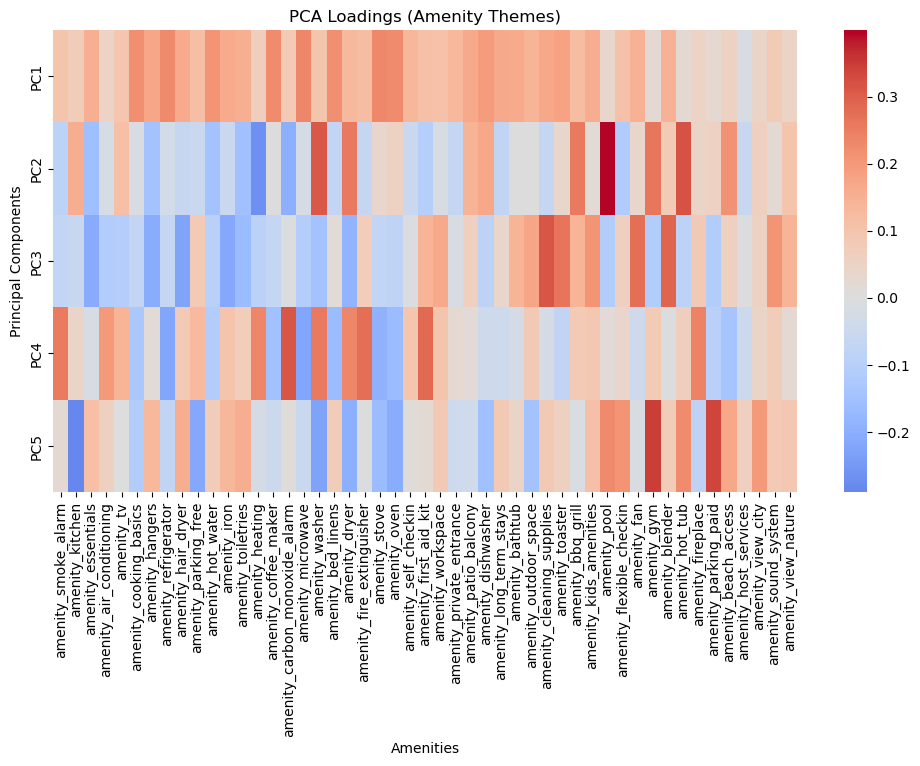

In [25]:
plt.figure(figsize=(12,6))
sns.heatmap(pca_loadings, cmap='coolwarm', center=0)

plt.title("PCA Loadings (Amenity Themes)")
plt.xlabel("Amenities")
plt.ylabel("Principal Components")

plt.show()

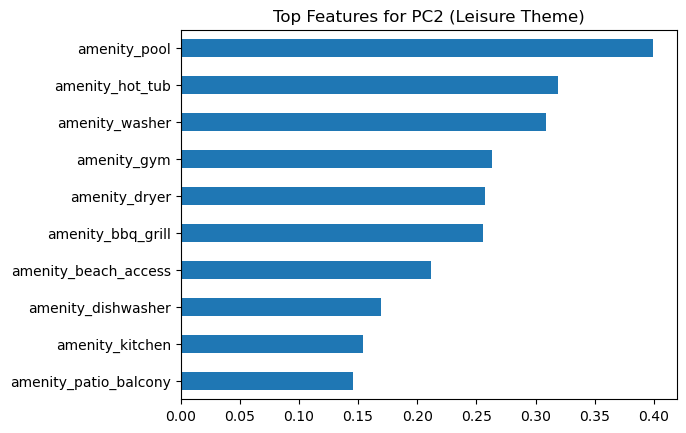

In [26]:
top_features = pca_loadings.T.sort_values(by='PC2', ascending=False).head(10)

top_features['PC2'].plot(kind='barh')
plt.title("Top Features for PC2 (Leisure Theme)")
plt.gca().invert_yaxis()
plt.show()

### Summary: 

I was curious to see how certain amenities grouped together, but I didn't get a very clear read. 
* PC1: Fully equipped, standard, livable listing
* PC2: Vacation / outdoor / leisure listing
* PC3: Multi-use living: family + longer stays + practical use (parking and kids amenities)
* PC4: Basic amenities plus a pool (didn't seem to cluster strongly)
* PC5: Basic amenities plus parking (suitable for an extended stay)

## Rare Amenity Analysis (Exploratory)


In [27]:
rare_amenities

['amenity_view_other',
 'amenity_view_water',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

In [28]:
# --- Mean presence of each rare amenity by city ---
city_amenities = df.groupby('city')[rare_amenities].mean()

city_amenities.sort_values(by=rare_amenities, ascending=False).head(10)

,amenity_view_other,amenity_view_water,amenity_ev_charger,amenity_musical_instruments,amenity_game_console,amenity_ski_access
city,,,,,,
Clark County,0.073987,0.000785,0.052792,0.017663,0.031989,0.001276
Broward,0.073635,0.086431,0.034315,0.012153,0.019946,0.001287
Hawaii,0.068395,0.204636,0.024490,0.007614,0.014720,0.000338
Bozeman,0.062232,0.000000,0.047210,0.027897,0.010730,0.012876
Dallas,0.061913,0.000640,0.057643,0.036080,0.032878,0.000427
Dever,0.051025,0.000456,0.037813,0.051481,0.041686,0.000456
New Orleans,0.045921,0.000326,0.011887,0.023775,0.011399,0.000000
Los Angeles,0.043909,0.024346,0.052264,0.038535,0.019661,0.000328
Austin,0.041109,0.000357,0.058231,0.052167,0.033173,0.000357


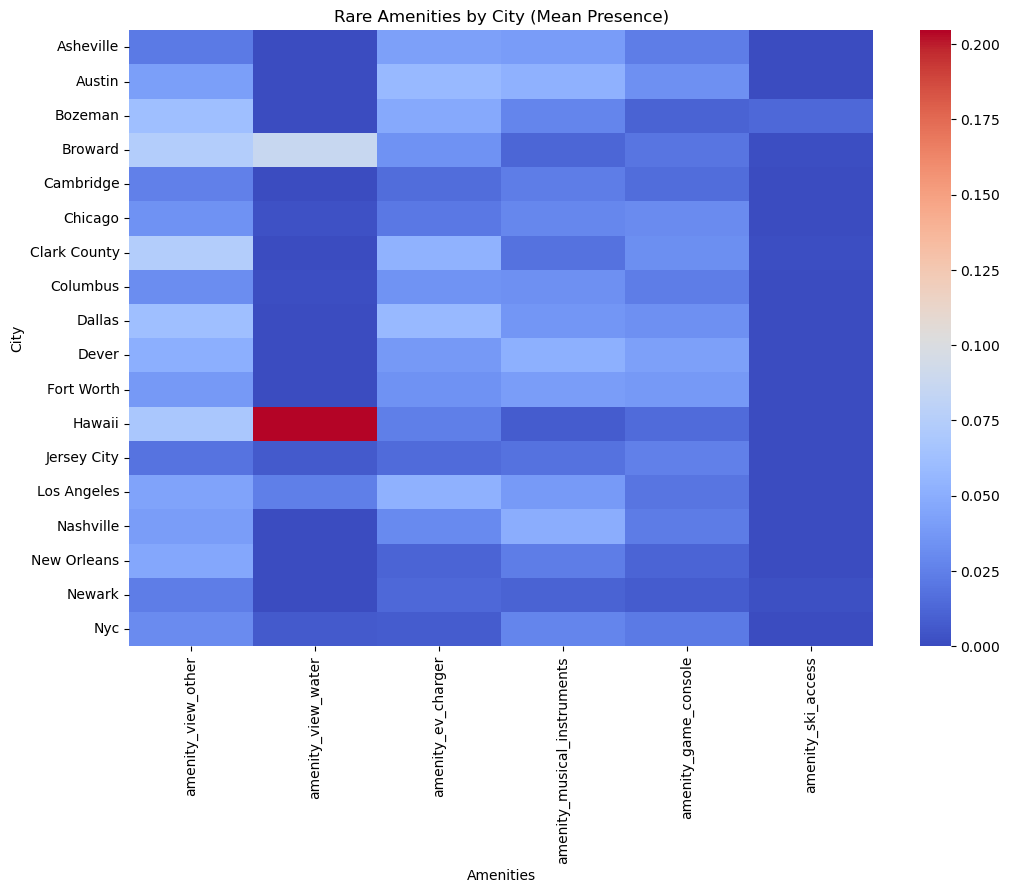

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(city_amenities, cmap='coolwarm')

plt.title("Rare Amenities by City (Mean Presence)")
plt.xlabel("Amenities")
plt.ylabel("City")

plt.show()

## Save CSV

In [30]:
df.to_csv('../data/processed/airbnb_preprocessed.csv', index=False)

print('Saved airbnb_preprocessed.csv:', df.shape)

Saved airbnb_preprocessed.csv: (153594, 82)


## Overview

In this stage, I prepared the dataset for modeling by making sure all features were in a usable format and ready for machine learning. Categorical variables like room type and amenities were already encoded during earlier steps. I confirmed that all features were numeric and consistent.


I also applied feature scaling using a StandardScaler for Ridge and Lasso regression (in next step). Finally, I split the dataset into training and testing sets (80/20) to allow for proper model evaluation and to reduce the risk of overfitting.


Overall, this step was focused on creating a clean, structured dataset that can be used reliably in the modeling phase.


<b>Next Steps:</b>
In the modeling phase, I will test different models to understand what drives Airbnb performance (bookings, potentially pricing as well). This includes building baseline linear models for interpretability, applying regularization techniques to address multicollinearity, and testing nonlinear models to capture more complex relationships.
The goal is to identify which features—such as location, bed/baths, and amenities are most predictive of demand and pricing, and to use those insights to inform what makes a high-performing listing.

<b>Overall goal:</b>
Given a specific location and market conditions, what type of Airbnb listing will consistently perform best in terms of bookings (and sustainable pricing)?

    For example: 

        For a defined area (city / zip code / radius), what combination of:

        * property size (bedrooms, bathrooms, accommodates)
        * amenity profile (baseline vs premium vs niche)
        * price range

        will maximize demand (reviews per month) while remaining competitive in that market?

        later: do images make a difference, if so, what qualities should they have? 